In [1]:
# Define the problem:
# Predict whether a passenger survived the Titanic disaster based on features.
objective = "Classification: Survived (Yes/No)"
success_criteria = "Accuracy > 80%"
constraints = "Limited features, missing values, imbalanced classes"
print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)


Objective: Classification: Survived (Yes/No)
Success Criteria: Accuracy > 80%
Constraints: Limited features, missing values, imbalanced classes


In [2]:
import pandas as pd                 # Load dataset (Titanic dataset from seaborn or CSV)
import seaborn as sns
df = sns.load_dataset("titanic")
print("Data shape:", df.shape)
print(df.head())


Data shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
# Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
# Drop duplicates
df.drop_duplicates(inplace=True)
# Encode categorical variables
df = pd.get_dummies(df, columns=['sex','class','embarked'], drop_first=True)
# Feature engineering: family size
df['family_size'] = df['sibsp'] + df['parch']
print(df.head())


   survived  pclass   age  sibsp  parch     fare    who  adult_male deck  \
0         0       3  22.0      1      0   7.2500    man        True  NaN   
1         1       1  38.0      1      0  71.2833  woman       False    C   
2         1       3  26.0      0      0   7.9250  woman       False  NaN   
3         1       1  35.0      1      0  53.1000  woman       False    C   
4         0       3  35.0      0      0   8.0500    man        True  NaN   

   embark_town alive  alone  sex_male  class_Second  class_Third  embarked_Q  \
0  Southampton    no  False      True         False         True       False   
1    Cherbourg   yes  False     False         False        False       False   
2  Southampton   yes   True     False         False         True       False   
3  Southampton   yes  False     False         False        False       False   
4  Southampton    no   True      True         False         True       False   

   embarked_S  family_size  
0        True            1  
1   

/tmp/ipykernel_3904/174372840.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_3904/174372840.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

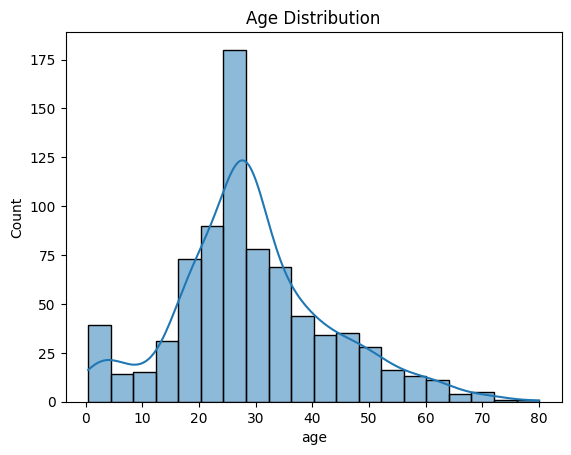

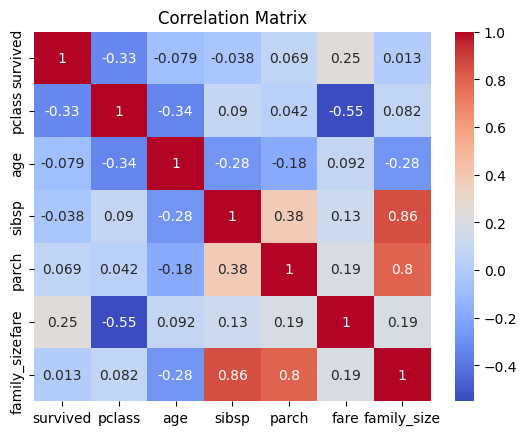

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram of age
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation matrix (numeric only)
corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [22]:
print(df.head())

   survived  pclass   age  sibsp  parch     fare    who  adult_male deck  \
0         0       3  22.0      1      0   7.2500    man        True  NaN   
1         1       1  38.0      1      0  71.2833  woman       False    C   
2         1       3  26.0      0      0   7.9250  woman       False  NaN   
3         1       1  35.0      1      0  53.1000  woman       False    C   
4         0       3  35.0      0      0   8.0500    man        True  NaN   

   embark_town alive  alone  sex_male  class_Second  class_Third  embarked_Q  \
0  Southampton    no  False      True         False         True       False   
1    Cherbourg   yes  False     False         False        False       False   
2  Southampton   yes   True     False         False         True       False   
3  Southampton   yes  False     False         False        False       False   
4  Southampton    no   True      True         False         True       False   

   embarked_S  family_size  
0        True            1  
1   

In [23]:
print(df.columns)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'who',
       'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'sex_male',
       'class_Second', 'class_Third', 'embarked_Q', 'embarked_S',
       'family_size'],
      dtype='object')


In [24]:
print(df.dtypes)

survived           int64
pclass             int64
age              float64
sibsp              int64
parch              int64
fare             float64
who               object
adult_male          bool
deck            category
embark_town       object
alive             object
alone               bool
sex_male            bool
class_Second        bool
class_Third         bool
embarked_Q          bool
embarked_S          bool
family_size        int64
dtype: object


In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

   survived  pclass   age  sibsp  parch     fare  adult_male  alone  sex_male  \
0         0       3  22.0      1      0   7.2500        True  False      True   
1         1       1  38.0      1      0  71.2833       False  False     False   
2         1       3  26.0      0      0   7.9250       False   True     False   
3         1       1  35.0      1      0  53.1000       False  False     False   
4         0       3  35.0      0      0   8.0500        True   True      True   

   class_Second  ...  who_woman  deck_B  deck_C  deck_D  deck_E  deck_F  \
0         False  ...      False   False   False   False   False   False   
1         False  ...       True   False    True   False   False   False   
2         False  ...       True   False   False   False   False   False   
3         False  ...       True   False    True   False   False   False   
4         False  ...      False   False   False   False   False   False   

   deck_G  embark_town_Queenstown  embark_town_Southampton  al

In [26]:
X = df_encoded.drop('survived', axis=1)

y = df_encoded['survived']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [29]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 1 1 0 1 1]


In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 100.0 %


Text(45.722222222222214, 0.5, 'Actual')

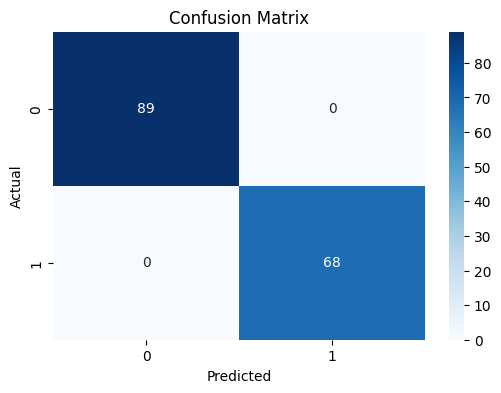

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")